In [1]:
#04_ccm_run.ipynb

In [2]:
# imports
import pandas as pd
import numpy as np
from pathlib import Path
import pyEDM
import matplotlib.pyplot as plt

In [30]:
# paths
DATA_DIR = Path("../../data")
PROCESSED_DIR = DATA_DIR / "processed" / "CY-Bench-01"
RESULTS_DIR = DATA_DIR / "results" / "CY-Bench-01"
PLOTS_DIR = Path("../../figures/CY-Bench-01")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# pair files
pair_files = {
    "ssm_ndvi": PROCESSED_DIR / "ccm_pair_ssm_ndvi.csv",
    "ssm_fpar": PROCESSED_DIR / "ccm_pair_ssm_fpar.csv",
    "ssm_yield": PROCESSED_DIR / "ccm_pair_ssm_yield.csv",
    "cwb_ssm": PROCESSED_DIR / "ccm_pair_cwb_ssm.csv",
    "tavg_cwb": PROCESSED_DIR / "ccm_pair_tavg_cwb.csv",
}

pair_files

{'ssm_ndvi': PosixPath('../../data/processed/CY-Bench-01/ccm_pair_ssm_ndvi.csv'),
 'ssm_fpar': PosixPath('../../data/processed/CY-Bench-01/ccm_pair_ssm_fpar.csv'),
 'ssm_yield': PosixPath('../../data/processed/CY-Bench-01/ccm_pair_ssm_yield.csv'),
 'cwb_ssm': PosixPath('../../data/processed/CY-Bench-01/ccm_pair_cwb_ssm.csv'),
 'tavg_cwb': PosixPath('../../data/processed/CY-Bench-01/ccm_pair_tavg_cwb.csv')}

In [5]:
# load pair tables
pair_tables = {name: pd.read_csv(path) for name, path in pair_files.items()}

for name, df_ in pair_tables.items():
    print(name, df_.shape, df_.columns.tolist())

ssm_ndvi (6715, 7) ['crop_name', 'country_code', 'adm_id', 'harvest_year', 'x', 'y', 'pair']
ssm_fpar (6715, 7) ['crop_name', 'country_code', 'adm_id', 'harvest_year', 'x', 'y', 'pair']
ssm_yield (6715, 7) ['crop_name', 'country_code', 'adm_id', 'harvest_year', 'x', 'y', 'pair']
cwb_ssm (6715, 7) ['crop_name', 'country_code', 'adm_id', 'harvest_year', 'x', 'y', 'pair']
tavg_cwb (6715, 7) ['crop_name', 'country_code', 'adm_id', 'harvest_year', 'x', 'y', 'pair']


In [6]:
# run settings
E_VALUES = [2, 3, 4, 5]
TAU = -1
TP = 0
SAMPLE = 50
SEED = 42
LIB_SIZES = "10 150 10"
MIN_SERIES_LEN = 10

In [7]:
# helper functions
def keep_eligible_units(df_pair, min_len=MIN_SERIES_LEN):
    counts = (
        df_pair.groupby("adm_id", as_index=False)
        .agg(n_years=("harvest_year", "nunique"))
    )
    good_ids = counts.loc[counts["n_years"] >= min_len, "adm_id"]
    out = df_pair[df_pair["adm_id"].isin(good_ids)].copy()
    out = out.sort_values(["adm_id", "harvest_year"]).reset_index(drop=True)
    return out


def make_ccm_block(df_pair):
    out = df_pair[["x", "y"]].copy().reset_index(drop=True)
    out.insert(0, "Time", np.arange(1, len(out) + 1))
    return out


def run_one_ccm(df_block, E, lib_sizes=LIB_SIZES, sample=SAMPLE, tau=TAU, tp=TP, seed=SEED):
    return pyEDM.CCM(
        dataFrame=df_block,
        columns="x",
        target="y",
        libSizes=lib_sizes,
        sample=sample,
        E=E,
        Tp=tp,
        tau=tau,
        seed=seed,
        noTime=True,
        showPlot=False,
    )

def get_forward_rho_col(res):
    cols = [c for c in res.columns if c != "LibSize"]
    forward = [c for c in cols if "x" in c and "y" in c]
    if forward:
        return forward[0]
    return cols[0]


In [8]:
# embedding scan
embedding_rows = []

for pair_name, df_pair in pair_tables.items():
    df_pair_ok = keep_eligible_units(df_pair, min_len=MIN_SERIES_LEN)
    df_block = make_ccm_block(df_pair_ok)

    for E in E_VALUES:
        res = run_one_ccm(df_block, E=E)
        rho_col = get_forward_rho_col(res)

        embedding_rows.append(
            {
                "pair_name": pair_name,
                "E": E,
                "n_rows": len(df_block),
                "rho_last": res[rho_col].iloc[-1],
            }
        )

embedding_scan = pd.DataFrame(embedding_rows)
embedding_scan

,pair_name,E,n_rows,rho_last
0,ssm_ndvi,2,6460,0.302755
1,ssm_ndvi,3,6460,0.381282
2,ssm_ndvi,4,6460,0.426231
3,ssm_ndvi,5,6460,0.452248
4,ssm_fpar,2,6460,0.153069
5,ssm_fpar,3,6460,0.227024
6,ssm_fpar,4,6460,0.276681
7,ssm_fpar,5,6460,0.308246
8,ssm_yield,2,6460,0.318654
9,ssm_yield,3,6460,0.391155


In [9]:
# choose best E
best_E = (
    embedding_scan.sort_values(["pair_name", "rho_last"], ascending=[True, False])
    .groupby("pair_name", as_index=False)
    .first()[["pair_name", "E", "rho_last"]]
    .rename(columns={"E": "best_E", "rho_last": "best_rho_last"})
)

best_E

,pair_name,best_E,best_rho_last
0,cwb_ssm,5,0.740139
1,ssm_fpar,5,0.308246
2,ssm_ndvi,5,0.452248
3,ssm_yield,5,0.467692
4,tavg_cwb,5,0.529380


In [10]:
# final CCM runs
ccm_results = {}
summary_rows = []

for pair_name, df_pair in pair_tables.items():
    df_pair_ok = keep_eligible_units(df_pair, min_len=MIN_SERIES_LEN)
    df_block = make_ccm_block(df_pair_ok)

    E_star = int(best_E.loc[best_E["pair_name"] == pair_name, "best_E"].iloc[0])
    res = run_one_ccm(df_block, E=E_star)
    ccm_results[pair_name] = res

    rho_cols = [c for c in res.columns if "rho" in c.lower()]
    lib_col = [c for c in res.columns if "libsize" in c.lower()]

    summary_rows.append(
        {
            "pair_name": pair_name,
            "best_E": E_star,
            "n_rows": len(df_block),
            "max_libsize": res[lib_col[0]].max() if lib_col else np.nan,
            "final_rho": res[rho_cols[0]].iloc[-1] if rho_cols else np.nan,
        }
    )

ccm_summary = pd.DataFrame(summary_rows).sort_values("pair_name").reset_index(drop=True)
ccm_summary

,pair_name,best_E,n_rows,max_libsize,final_rho
0,cwb_ssm,5,6460,150,NaN
1,ssm_fpar,5,6460,150,NaN
2,ssm_ndvi,5,6460,150,NaN
3,ssm_yield,5,6460,150,NaN
4,tavg_cwb,5,6460,150,NaN


In [11]:
# save tables
embedding_scan.to_csv(RESULTS_DIR / "ccm_embedding_scan.csv", index=False)
best_E.to_csv(RESULTS_DIR / "ccm_best_E.csv", index=False)
ccm_summary.to_csv(RESULTS_DIR / "ccm_summary.csv", index=False)

for pair_name, res in ccm_results.items():
    res.to_csv(RESULTS_DIR / f"ccm_result_{pair_name}.csv", index=False)

print("saved CCM outputs")

saved CCM outputs


In [12]:
# null test settings
NULL_REPS = 50
NULL_PAIR = "ssm_yield"
NULL_E = int(best_E.loc[best_E["pair_name"] == NULL_PAIR, "best_E"].iloc[0])
NULL_LIB_SIZES = LIB_SIZES

In [13]:
# null test helper
def make_null_block(df_pair, seed=0):
    rng = np.random.default_rng(seed)
    out = df_pair[["x", "y"]].copy().reset_index(drop=True)
    out["y"] = rng.permutation(out["y"].to_numpy())
    out.insert(0, "Time", np.arange(1, len(out) + 1))
    return out

In [14]:
# real vs null for one pair
real_df = keep_eligible_units(pair_tables[NULL_PAIR], min_len=MIN_SERIES_LEN)
real_block = make_ccm_block(real_df)
real_res = run_one_ccm(real_block, E=NULL_E)

real_rho_col = get_forward_rho_col(real_res)
real_final = float(real_res[real_rho_col].iloc[-1])

null_vals = []
for i in range(NULL_REPS):
    null_block = make_null_block(real_df, seed=SEED + i)
    null_res = pyEDM.CCM(
        dataFrame=null_block,
        columns="x",
        target="y",
        libSizes=NULL_LIB_SIZES,
        sample=SAMPLE,
        E=NULL_E,
        Tp=TP,
        tau=TAU,
        seed=SEED + i,
        noTime=True,
        showPlot=False,
    )
    null_rho_col = get_forward_rho_col(null_res)
    null_vals.append(float(null_res[null_rho_col].iloc[-1]))

null_vals = np.array(null_vals)

In [15]:
# null summary
null_summary = pd.DataFrame(
    {
        "pair_name": [NULL_PAIR],
        "E": [NULL_E],
        "real_final_rho": [real_final],
        "null_mean_rho": [null_vals.mean()],
        "null_std_rho": [null_vals.std(ddof=1)],
        "null_p95_rho": [np.quantile(null_vals, 0.95)],
        "null_pvalue_right_tail": [(np.sum(null_vals >= real_final) + 1) / (len(null_vals) + 1)],
    }
)

null_summary

,pair_name,E,real_final_rho,null_mean_rho,null_std_rho,null_p95_rho,null_pvalue_right_tail
0,ssm_yield,5,0.467692,-0.000172,0.003337,0.005205,0.019608


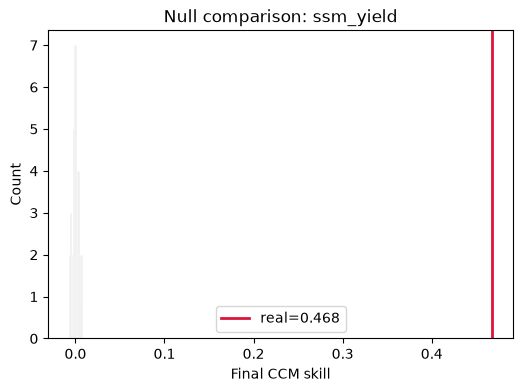

In [20]:
# null plot
plt.figure(figsize=(6, 4))
plt.hist(null_vals, bins=15, alpha=0.75, color="gray", edgecolor="white")
plt.axvline(real_final, color="crimson", linewidth=2, label=f"real={real_final:.3f}")
plt.title(f"Null comparison: {NULL_PAIR}")
plt.xlabel("Final CCM skill")
plt.ylabel("Count")
plt.legend()
plt.savefig(PLOTS_DIR / f"ccm_null_{NULL_PAIR}.png", dpi=150, bbox_inches="tight")

In [21]:
# save null summary
null_summary.to_csv(RESULTS_DIR / f"ccm_null_summary_{NULL_PAIR}.csv", index=False)
print("saved null summary")

saved null summary


In [22]:
# plot convergence
for pair_name, res in ccm_results.items():
    print(pair_name, res.columns.tolist())

    lib_col = [c for c in res.columns if c.lower() == "libsize"]
    map_cols = [c for c in res.columns if c != "LibSize"]

    if not lib_col or len(map_cols) < 2:
        print(f"Skipping {pair_name}: unexpected columns")
        continue

    plt.figure(figsize=(6, 4))
    plt.plot(res[lib_col[0]], res[map_cols[0]], marker="o", label=map_cols[0])
    plt.plot(res[lib_col[0]], res[map_cols[1]], marker="s", label=map_cols[1])
    plt.title(f"CCM convergence: {pair_name}")
    plt.xlabel("Library size")
    plt.ylabel("Cross-map skill")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"ccm_plot_{pair_name}.png", dpi=150, bbox_inches="tight")
    plt.close()

print("saved CCM plots")

ssm_ndvi ['LibSize', 'x:y', 'y:x']
ssm_fpar ['LibSize', 'x:y', 'y:x']
ssm_yield ['LibSize', 'x:y', 'y:x']
cwb_ssm ['LibSize', 'x:y', 'y:x']
tavg_cwb ['LibSize', 'x:y', 'y:x']
saved CCM plots


In [23]:
test = pyEDM.CCM(
    dataFrame=make_ccm_block(keep_eligible_units(pair_tables["ssm_ndvi"])),
    columns="x",
    target="y",
    libSizes="10 80 10",
    sample=10,
    E=2,
    tau=-1,
    Tp=0,
    noTime=True,
    showPlot=False
)

print(test.head())
print(test.columns.tolist())

   LibSize       x:y       y:x
0       10  0.116756  0.079729
1       20  0.178264  0.126414
2       30  0.235960  0.182514
3       40  0.225882  0.147713
4       50  0.256051  0.180497
['LibSize', 'x:y', 'y:x']


In [24]:
# E sensitivity sweep
SENSITIVITY_PAIRS = ["ssm_ndvi", "ssm_fpar", "ssm_yield"]
E_SWEEP = [2, 3, 4, 5, 6, 7, 8]

e_sensitivity_rows = []
e_sensitivity_results = {}

for pair_name in SENSITIVITY_PAIRS:
    df_pair = keep_eligible_units(pair_tables[pair_name], min_len=MIN_SERIES_LEN)
    df_block = make_ccm_block(df_pair)

    pair_runs = []

    for E in E_SWEEP:
        res = run_one_ccm(df_block, E=E)
        lib_col = [c for c in res.columns if c == "LibSize"][0]
        map_cols = [c for c in res.columns if c != "LibSize"]

        forward_col = [c for c in map_cols if "x" in c and "y" in c]
        reverse_col = [c for c in map_cols if "y" in c and "x" in c]

        forward_col = forward_col[0] if forward_col else map_cols[0]
        reverse_col = reverse_col[0] if reverse_col else map_cols[1]

        forward_final = float(res[forward_col].iloc[-1])
        reverse_final = float(res[reverse_col].iloc[-1])
        asymmetry = forward_final - reverse_final

        e_sensitivity_rows.append(
            {
                "pair_name": pair_name,
                "E": E,
                "n_rows": len(df_block),
                "max_libsize": int(res[lib_col].iloc[-1]),
                "forward_col": forward_col,
                "reverse_col": reverse_col,
                "forward_final_rho": forward_final,
                "reverse_final_rho": reverse_final,
                "asymmetry_forward_minus_reverse": asymmetry,
            }
        )

        tmp = res.copy()
        tmp["pair_name"] = pair_name
        tmp["E"] = E
        pair_runs.append(tmp)

    e_sensitivity_results[pair_name] = pd.concat(pair_runs, axis=0, ignore_index=True)

e_sensitivity_summary = pd.DataFrame(e_sensitivity_rows)
e_sensitivity_summary

,pair_name,E,n_rows,max_libsize,forward_col,reverse_col,forward_final_rho,reverse_final_rho,asymmetry_forward_minus_reverse
0,ssm_ndvi,2,6460,150,x:y,x:y,0.302755,0.302755,0.0
1,ssm_ndvi,3,6460,150,x:y,x:y,0.381282,0.381282,0.0
2,ssm_ndvi,4,6460,150,x:y,x:y,0.426231,0.426231,0.0
3,ssm_ndvi,5,6460,150,x:y,x:y,0.452248,0.452248,0.0
4,ssm_ndvi,6,6460,150,x:y,x:y,0.463858,0.463858,0.0
5,ssm_ndvi,7,6460,150,x:y,x:y,0.470302,0.470302,0.0
6,ssm_ndvi,8,6460,150,x:y,x:y,0.474021,0.474021,0.0
7,ssm_fpar,2,6460,150,x:y,x:y,0.153069,0.153069,0.0
8,ssm_fpar,3,6460,150,x:y,x:y,0.227024,0.227024,0.0
9,ssm_fpar,4,6460,150,x:y,x:y,0.276681,0.276681,0.0


In [25]:
# best E by asymmetry
best_E_by_asymmetry = (
    e_sensitivity_summary
    .sort_values(
        ["pair_name", "asymmetry_forward_minus_reverse", "forward_final_rho"],
        ascending=[True, False, False]
    )
    .groupby("pair_name", as_index=False)
    .first()
)

best_E_by_asymmetry

,pair_name,E,n_rows,max_libsize,forward_col,reverse_col,forward_final_rho,reverse_final_rho,asymmetry_forward_minus_reverse
0,ssm_fpar,8,6460,150,x:y,x:y,0.331319,0.331319,0.0
1,ssm_ndvi,8,6460,150,x:y,x:y,0.474021,0.474021,0.0
2,ssm_yield,8,6460,150,x:y,x:y,0.514012,0.514012,0.0


In [26]:
# plot E sensitivity
for pair_name in SENSITIVITY_PAIRS:
    sub = e_sensitivity_summary[e_sensitivity_summary["pair_name"] == pair_name].copy()

    plt.figure(figsize=(7, 4.5))
    plt.plot(sub["E"], sub["forward_final_rho"], marker="o", label="forward final rho")
    plt.plot(sub["E"], sub["reverse_final_rho"], marker="s", label="reverse final rho")
    plt.plot(sub["E"], sub["asymmetry_forward_minus_reverse"], marker="^", label="forward - reverse")

    plt.title(f"E sensitivity: {pair_name}")
    plt.xlabel("Embedding dimension E")
    plt.ylabel("Final CCM skill")
    plt.xticks(E_SWEEP)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"ccm_E_sensitivity_{pair_name}.png", dpi=150, bbox_inches="tight")
    plt.close()

print("saved E sensitivity plots")

saved E sensitivity plots


In [27]:
# save E sensitivity outputs
e_sensitivity_summary.to_csv(RESULTS_DIR / "ccm_E_sensitivity_summary.csv", index=False)
best_E_by_asymmetry.to_csv(RESULTS_DIR / "ccm_E_best_by_asymmetry.csv", index=False)

for pair_name, df_res in e_sensitivity_results.items():
    df_res.to_csv(RESULTS_DIR / f"ccm_E_sensitivity_runs_{pair_name}.csv", index=False)

print("saved E sensitivity outputs")

saved E sensitivity outputs


In [28]:
# final summary table

def extract_final_map_scores(res):
    lib_col = "LibSize" if "LibSize" in res.columns else [c for c in res.columns if c.lower() == "libsize"][0]
    map_cols = [c for c in res.columns if c != lib_col]

    forward_col = [c for c in map_cols if "x" in c and "y" in c]
    reverse_col = [c for c in map_cols if "y" in c and "x" in c]

    if forward_col:
        forward_col = forward_col[0]
    else:
        forward_col = map_cols[0]

    if reverse_col:
        reverse_col = reverse_col[0]
    else:
        reverse_col = map_cols[1]

    return lib_col, forward_col, reverse_col


final_rows = []

for pair_name in ["ssm_ndvi", "ssm_fpar", "ssm_yield"]:
    df_pair = keep_eligible_units(pair_tables[pair_name], min_len=MIN_SERIES_LEN)
    df_block = make_ccm_block(df_pair)

    E_star = int(best_E_by_asymmetry.loc[best_E_by_asymmetry["pair_name"] == pair_name, "E"].iloc[0])
    real_res = run_one_ccm(df_block, E=E_star)
    lib_col, forward_col, reverse_col = extract_final_map_scores(real_res)

    real_final_forward = float(real_res[forward_col].iloc[-1])
    real_final_reverse = float(real_res[reverse_col].iloc[-1])

    null_vals = []
    for i in range(NULL_REPS):
        null_block = make_null_block(df_pair, seed=SEED + i)
        null_res = pyEDM.CCM(
            dataFrame=null_block,
            columns="x",
            target="y",
            libSizes=LIB_SIZES,
            sample=SAMPLE,
            E=E_star,
            Tp=TP,
            tau=TAU,
            seed=SEED + i,
            noTime=True,
            showPlot=False,
        )
        _, null_forward_col, _ = extract_final_map_scores(null_res)
        null_vals.append(float(null_res[null_forward_col].iloc[-1]))

    null_vals = np.array(null_vals)
    null_mean = float(null_vals.mean())
    null_std = float(null_vals.std(ddof=1))
    null_p95 = float(np.quantile(null_vals, 0.95))
    null_pvalue = float((np.sum(null_vals >= real_final_forward) + 1) / (len(null_vals) + 1))

    final_rows.append(
        {
            "pair_name": pair_name,
            "best_E": E_star,
            "real_forward_final_rho": real_final_forward,
            "real_reverse_final_rho": real_final_reverse,
            "real_asymmetry": real_final_forward - real_final_reverse,
            "null_mean_forward_rho": null_mean,
            "null_std_forward_rho": null_std,
            "null_p95_forward_rho": null_p95,
            "null_pvalue_right_tail": null_pvalue,
        }
    )

final_summary = pd.DataFrame(final_rows).sort_values("pair_name").reset_index(drop=True)
final_summary

,pair_name,best_E,real_forward_final_rho,real_reverse_final_rho,real_asymmetry,null_mean_forward_rho,null_std_forward_rho,null_p95_forward_rho,null_pvalue_right_tail
0,ssm_fpar,8,0.331319,0.331319,0.0,0.000284,0.003499,0.006175,0.019608
1,ssm_ndvi,8,0.474021,0.474021,0.0,0.000201,0.003507,0.007137,0.019608
2,ssm_yield,8,0.514012,0.514012,0.0,-0.000356,0.003503,0.004364,0.019608


In [29]:
# save final summary
final_summary.to_csv(RESULTS_DIR / "ccm_final_summary_current_dataset.csv", index=False)
final_summary

,pair_name,best_E,real_forward_final_rho,real_reverse_final_rho,real_asymmetry,null_mean_forward_rho,null_std_forward_rho,null_p95_forward_rho,null_pvalue_right_tail
0,ssm_fpar,8,0.331319,0.331319,0.0,0.000284,0.003499,0.006175,0.019608
1,ssm_ndvi,8,0.474021,0.474021,0.0,0.000201,0.003507,0.007137,0.019608
2,ssm_yield,8,0.514012,0.514012,0.0,-0.000356,0.003503,0.004364,0.019608
